In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [2]:
df_train = pd.read_csv(r"D:\AI Internship\Day 11\MNIST dataset\train.csv")
df_test = pd.read_csv(r"D:\AI Internship\Day 11\MNIST dataset\test.csv")

In [3]:
print(df_train.columns[:5])
print(df_test.columns[:5])

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3'], dtype='str')
Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4'], dtype='str')


In [4]:
X = df_train.drop('label', axis=1).values
y = df_train['label'].values

In [5]:
X = X.astype('float32') / 255.0
X = X.reshape(-1, 28, 28, 1)


In [6]:
print(X.shape)

(42000, 28, 28, 1)


In [7]:
y = to_categorical(y, num_classes=10)

print(y.shape)

(42000, 10)


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print(X_train.shape)
print(X_val.shape)

print(y_train.shape)
print(y_val.shape)  #eeyo hinje niche waro output awww

(33600, 28, 28, 1)
(8400, 28, 28, 1)
(33600, 10)
(8400, 10)


In [10]:
cnn = Sequential([

    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D(pool_size=(2,2)),

    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')

])

c:\Users\hplap\miniconda3\envs\ml-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
early_stop= EarlyStopping(
monitor='val_loss',
patience=3,
restore_best_weights=True
 )

In [14]:
history = cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 27s 24ms/step - accuracy: 0.9189 - loss: 0.2636 - val_accuracy: 0.9800 - val_loss: 0.0641
Epoch 2/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9725 - loss: 0.0939 - val_accuracy: 0.9855 - val_loss: 0.0458
Epoch 3/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.9799 - loss: 0.0660 - val_accuracy: 0.9855 - val_loss: 0.0441
Epoch 4/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9833 - loss: 0.0543 - val_accuracy: 0.9879 - val_loss: 0.0374
Epoch 5/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.9851 - loss: 0.0475 - val_accuracy: 0.9887 - val_loss: 0.0361
Epoch 6/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.9882 - loss: 0.0369 - val_accuracy: 0.9899 - val_loss: 0.0357
Epoch 7/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.9896 - loss: 0.0322 - val_accuracy: 0.9912 - val_loss: 0.0316
Epoch 8/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.9904 -

In [15]:
loss, accuracy = cnn.evaluate(X_val, y_val)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

263/263 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9924 - loss: 0.0315
Validation Loss : 0.031491637229919434
Validation Accuracy : 0.9923809766769409


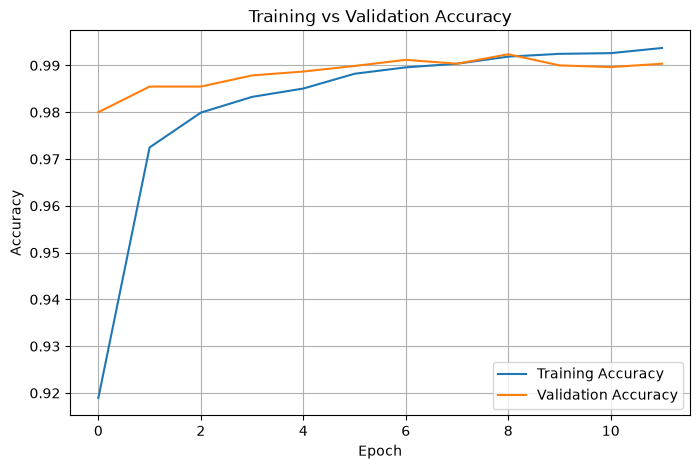

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()